# Figure S6j — Aδ-HTMR dorsal vs ventral branches, paired comparison

Complete collateral arbors of **8 Aδ-HTMRs** reconstructed in the dSC1 volume. For each
axodendritic synapse, the number of axoaxonic synapses within 4 µm of cable length is
counted; synapses are then split into dorsal and ventral terminal branches and averaged
per neuron, giving one paired observation per neuron.

**Input.** `../data/meshwork_h5/adhtmr/*.h5`. **Runs offline — no CAVE access.**

**Statistics.** Wilcoxon signed-rank test on the 8 pairs.

> The published legend quotes p = 1.17 × 10⁻², which is the **one-sided** p (two-sided
> p / 2). Both are printed below.


In [1]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.size"] = 6

CM = 1 / 2.54


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from meshparty import meshwork

H5_DIR = Path("../data/meshwork_h5")
SUBTYPE_CSV = Path("../data/meshwork_h5_subtypes.csv")
NM_TO_UM = 1e-3


def load(coord, subdir=""):
    """Load one meshwork .h5 by its 'x_y_z' coordinate string."""
    return meshwork.load_meshwork(H5_DIR / subdir / f"{coord}.h5")


def syn_indices(neuron):
    """Mesh indices of axodendritic and axoaxonic synapses.

    The sensory neuron is the reference cell in these meshwork files, so
    `pre_syn` = synapses it makes onto dendrites (axodendritic) and
    `post_syn` = synapses made onto it (axoaxonic).
    """
    pre = getattr(neuron.anno, "pre_syn", None)
    post = getattr(neuron.anno, "post_syn", None)
    return (np.asarray([] if pre is None else pre.mesh_index, dtype=int),
            np.asarray([] if post is None else post.mesh_index, dtype=int))


def distance_to_tips_um(neuron, idx):
    """Path distance (µm) from each synapse to its nearest axon tip."""
    tips = neuron.end_points
    if len(idx) == 0 or len(tips) == 0:
        return np.array([])
    return np.min(neuron.distance_between(idx, tips), axis=1) * NM_TO_UM


/Users/wangchu/opt/anaconda3/lib/python3.8/site-packages/python_jsonschema_objects/__init__.py:113: UserWarning: Schema id not specified. Defaulting to 'self'
  warnings.warn("Schema id not specified. Defaulting to 'self'")


In [3]:
def distance_to_nearest_um(neuron, idx_from, idx_to):
    """Path distance (µm) from each `idx_from` synapse to the nearest `idx_to` synapse."""
    if len(idx_from) == 0 or len(idx_to) == 0:
        return np.array([])
    return np.min(neuron.distance_between(idx_from, idx_to), axis=1) * NM_TO_UM


In [4]:
RADIUS_UM = 4.0
Y_SPLIT = 140_800          # nm; mesh y coordinate separating dorsal from ventral

# The 8 Aδ-HTMRs with fully reconstructed collateral arbors, by .h5 coordinate.
ADHTMR_COORDS = [
    "27411_7536_137", "12488_2097_528", "28564_4895_199", "25370_3492_889",
    "15124_2070_1078", "31399_2428_242", "9240_8289_123", "21712_6746_117",
]


In [5]:
rows = []
for coord in ADHTMR_COORDS:
    neuron = load(coord, subdir="adhtmr")
    pre_idx, post_idx = syn_indices(neuron)
    if len(pre_idx) == 0:
        print(f"{coord}: no axodendritic synapses")
        continue

    if len(post_idx) == 0:
        counts = np.zeros(len(pre_idx), dtype=int)
    else:
        dmat = neuron.distance_between(pre_idx, post_idx)      # nm
        counts = (dmat <= RADIUS_UM * 1000.0).sum(axis=1)

    layer = np.where(neuron.mesh.vertices[pre_idx][:, 1] <= Y_SPLIT,
                     "dorsal", "ventral")
    for c, l in zip(counts, layer):
        rows.append({"coord": coord, "layer": l, "n_aa_within_4um": int(c)})

df = pd.DataFrame(rows)
paired = (df.groupby(["coord", "layer"])["n_aa_within_4um"].mean()
            .unstack("layer").dropna(subset=["dorsal", "ventral"]))
print(paired.round(3).to_string())
print(f"\n{len(paired)} neurons with both dorsal and ventral axodendritic synapses")


layer            dorsal  ventral
coord                           
12488_2097_528    1.056    0.909
15124_2070_1078   1.196    0.819
21712_6746_117    1.312    0.750
25370_3492_889    0.764    0.000
27411_7536_137    1.015    0.648
28564_4895_199    0.842    0.500
31399_2428_242    0.212    0.203
9240_8289_123     0.470    0.562

8 neurons with both dorsal and ventral axodendritic synapses


In [6]:
from scipy.stats import wilcoxon

dorsal = paired["dorsal"].to_numpy()
ventral = paired["ventral"].to_numpy()

stat, p_two = wilcoxon(dorsal, ventral)
p_one = p_two / 2 if dorsal.mean() > ventral.mean() else 1 - p_two / 2

print(f"n pairs        = {len(dorsal)}")
print(f"dorsal  mean   = {dorsal.mean():.3f} ± {dorsal.std(ddof=1):.3f} (SD)")
print(f"ventral mean   = {ventral.mean():.3f} ± {ventral.std(ddof=1):.3f} (SD)")
print(f"Wilcoxon statistic = {stat:.3f}")
print(f"  two-sided p = {p_two:.4g}")
print(f"  one-sided p = {p_one:.4g}   <- value reported in the legend")


n pairs        = 8
dorsal  mean   = 0.858 ± 0.371 (SD)
ventral mean   = 0.549 ± 0.311 (SD)
Wilcoxon statistic = 2.000
  two-sided p = 0.02344
  one-sided p = 0.01172   <- value reported in the legend


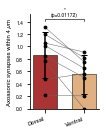

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.0 * CM, 5.0 * CM))
x = np.array([0, 1])

ax.bar(x, [dorsal.mean(), ventral.mean()],
       yerr=[dorsal.std(ddof=1), ventral.std(ddof=1)],
       width=0.6, capsize=3, color=["#a33", "#e0b080"],
       edgecolor="black", linewidth=0.5, zorder=1)

# paired lines, one per neuron
for d, v in zip(dorsal, ventral):
    ax.plot(x, [d, v], color="0.4", lw=0.5, zorder=2)
ax.scatter(np.zeros_like(dorsal), dorsal, s=8, color="black", zorder=3)
ax.scatter(np.ones_like(ventral), ventral, s=8, color="black", zorder=3)

y = max(dorsal.max(), ventral.max()) * 1.08
ax.plot([0, 0, 1, 1], [y, y * 1.02, y * 1.02, y], lw=0.6, color="black")
stars = "***" if p_one < 1e-3 else "**" if p_one < 1e-2 else "*" if p_one < 0.05 else "n.s."
ax.text(0.5, y * 1.04, f"{stars}\n(p={p_one:.4g})", ha="center", va="bottom", fontsize=5)

ax.set_xticks(x)
ax.set_xticklabels(["Dorsal", "Ventral"], rotation=20, ha="right", fontsize=6)
ax.set_ylabel("Axoaxonic synapses within 4 µm", fontsize=6)
ax.tick_params(axis="y", labelsize=5)
ax.grid(False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("figureS6j_adhtmr_dorsal_vs_ventral.svg", format="svg", dpi=300)
plt.show()
